# Practical Assignment 03: Performance Evaluation of Regression Model





## Import required libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make plots look clean
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries imported successfully!")

Libraries imported successfully!


## Load the dataset

In [9]:
# Load the CSV file saved in the same folder as this notebook
data = pd.read_csv("salary.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)
display(data.head())

Dataset loaded successfully!
Dataset shape: (373, 9)


,age,education_level,years_exp,salary,is_female,is_male,is_junior,is_senior,is_director
0,32.0,0,5.0,90000.0,0,1,0,0,0
1,28.0,1,3.0,65000.0,1,0,0,0,0
2,45.0,2,15.0,150000.0,0,1,0,1,0
3,36.0,0,7.0,60000.0,1,0,0,0,0
4,52.0,1,20.0,200000.0,0,1,0,0,1


##  Explore and clean the data

In [12]:
print("Column names:")
print(data.columns.tolist())

required_columns = ['age', 'years_exp', 'education_level', 'salary']
missing_columns = [col for col in required_columns if col not in data.columns]
if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}. "
        f"Available columns: {data.columns.tolist()}"
    )

# Keep only the three input features and the target
data = data[required_columns].copy()

# Convert required columns to numeric; invalid values become NaN
for col in required_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("\nMissing values before cleaning:")
display(data.isnull().sum().to_frame("Missing values"))

# Remove rows with missing values in the selected columns
data = data.dropna(subset=required_columns).copy()

print("Shape after removing missing values:", data.shape)
print("\nSummary statistics:")
display(data.describe().round(2))

if len(data) < 5:
    raise ValueError("The dataset has too few valid rows for a reliable train-test split.")

Column names:
['age', 'education_level', 'years_exp', 'salary', 'is_female', 'is_male', 'is_junior', 'is_senior', 'is_director']

Missing values before cleaning:


,Missing values
age,0
years_exp,0
education_level,0
salary,0


Shape after removing missing values: (373, 4)

Summary statistics:


,age,years_exp,education_level,salary
count,373.00,373.00,373.00,373.00
mean,37.43,10.03,0.54,100577.35
std,7.07,6.56,0.72,48240.01
min,23.00,0.00,0.00,350.00
25%,31.00,4.00,0.00,55000.00
50%,36.00,9.00,0.00,95000.00
75%,44.00,15.00,1.00,140000.00
max,53.00,25.00,2.00,250000.00


##  Select input features and target

In [14]:
X = data[['age', 'years_exp', 'education_level']]
y = data['salary']

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nSelected input features:", X.columns.tolist())
print("Target variable: salary")

Input feature shape: (373, 3)
Target shape: (373,)

Selected input features: ['age', 'years_exp', 'education_level']
Target variable: salary


## Split the dataset into training and testing sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 298
Testing samples: 75


##  Train the scikit-learn Linear Regression model

In [18]:
# Standardize features for consistent preprocessing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred_lr = model.predict(X_test_scaled)

print("Linear Regression model trained successfully!")
print("Intercept:", round(float(model.intercept_), 4))
print("Coefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"  {feature}: {coefficient:.4f}")

Linear Regression model trained successfully!
Intercept: 100101.8456
Coefficients:
  age: 22521.1633
  years_exp: 15862.3151
  education_level: 10508.9396


##  Evaluate the Linear Regression model

In [20]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}

lr_metrics = regression_metrics(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-" * 36)
for metric, value in lr_metrics.items():
    print(f"{metric:10s}: {value:,.4f}")

Linear Regression Performance
------------------------------------
MAE       : 11,328.0130
MSE       : 262,458,894.4315
RMSE      : 16,200.5832
R2 Score  : 0.8905


## Plot actual vs. predicted salary (Linear Regression)

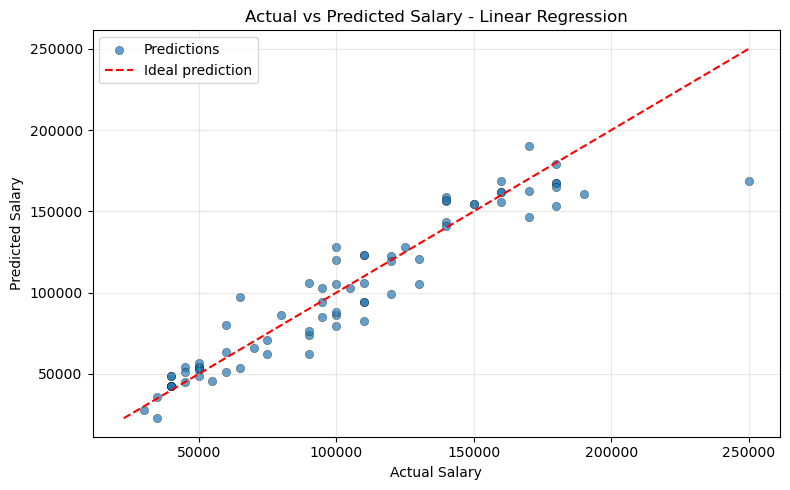

In [22]:
plt.figure()
plt.scatter(y_test, y_pred_lr, alpha=0.7, edgecolor='black', linewidth=0.3, label='Predictions')

lower = min(float(y_test.min()), float(np.min(y_pred_lr)))
upper = max(float(y_test.max()), float(np.max(y_pred_lr)))
plt.plot([lower, upper], [lower, upper], 'r--', label='Ideal prediction')

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary - Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

##  Implement Gradient Descent from scratch

Gradient Descent is implemented for multiple input features. The input features and target are standardized during optimization to keep the updates numerically stable. Predictions are converted back to the original salary scale before evaluating the metrics.

In [24]:
# Standardize target for stable Gradient Descent updates
y_mean = y_train.mean()
y_std = y_train.std()
if y_std == 0:
    raise ValueError("Salary has no variation in the training data.")

y_train_scaled = ((y_train.to_numpy() - y_mean) / y_std)

# Initialize weights and bias
n_samples, n_features = X_train_scaled.shape
weights = np.zeros(n_features)
bias = 0.0

learning_rate = 0.01
epochs = 1000
cost_history = []

# Batch Gradient Descent
for epoch in range(epochs):
    y_hat = X_train_scaled @ weights + bias
    error = y_hat - y_train_scaled

    dw = (2 / n_samples) * (X_train_scaled.T @ error)
    db = (2 / n_samples) * np.sum(error)

    weights -= learning_rate * dw
    bias -= learning_rate * db

    # Record mean squared error after the parameter update
    updated_pred = X_train_scaled @ weights + bias
    cost = np.mean((updated_pred - y_train_scaled) ** 2)
    cost_history.append(cost)

print("Gradient Descent completed!")
print("Final standardized weights:", np.round(weights, 4))
print("Final standardized bias:", round(float(bias), 4))
print("Final training cost:", round(float(cost_history[-1]), 6))

Gradient Descent completed!
Final standardized weights: [0.4229 0.3773 0.2167]
Final standardized bias: 0.0
Final training cost: 0.107628


##  Evaluate the Gradient Descent model

In [26]:
# Predict in standardized target scale, then convert to original salary units
y_pred_gd_scaled = X_test_scaled @ weights + bias
y_pred_gd = y_pred_gd_scaled * y_std + y_mean

gd_metrics = regression_metrics(y_test, y_pred_gd)

print("Gradient Descent Performance")
print("-" * 36)
for metric, value in gd_metrics.items():
    print(f"{metric:10s}: {value:,.4f}")

Gradient Descent Performance
------------------------------------
MAE       : 11,214.7617
MSE       : 256,946,980.1866
RMSE      : 16,029.5658
R2 Score  : 0.8928


## Plot Gradient Descent cost vs. epoch

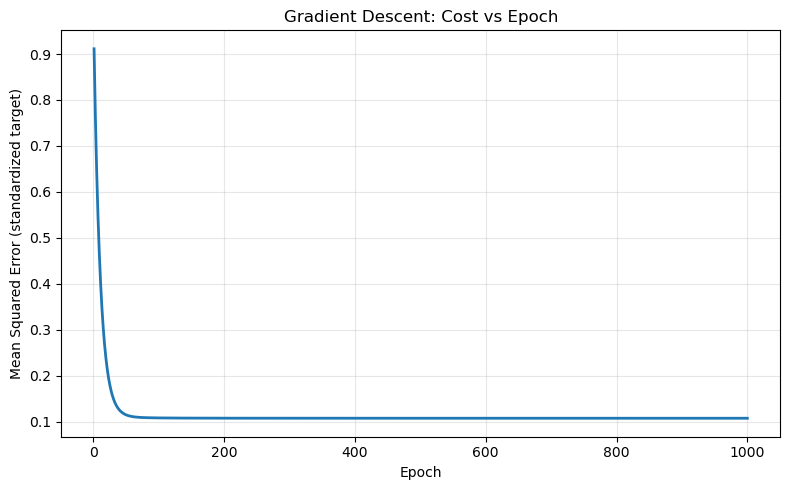

In [28]:
plt.figure()
plt.plot(range(1, epochs + 1), cost_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (standardized target)")
plt.title("Gradient Descent: Cost vs Epoch")
plt.tight_layout()
plt.show()

##  Compare both models

In [30]:
comparison = pd.DataFrame(
    [lr_metrics, gd_metrics],
    index=['Scikit-learn Linear Regression', 'Gradient Descent']
)
comparison.index.name = "Model"
display(comparison.round(4))

print("Note: Lower MAE, MSE and RMSE indicate smaller prediction errors.")
print("An R² score closer to 1 indicates that the model explains more variance.")

,MAE,MSE,RMSE,R2 Score
Model,,,,
Scikit-learn Linear Regression,11328.0130,2.624589e+08,16200.5832,0.8905
Gradient Descent,11214.7617,2.569470e+08,16029.5658,0.8928


Note: Lower MAE, MSE and RMSE indicate smaller prediction errors.
An R² score closer to 1 indicates that the model explains more variance.


##  Display sample predictions

In [32]:
results = X_test.copy()
results['Actual Salary'] = y_test
results['LR Predicted Salary'] = y_pred_lr
results['GD Predicted Salary'] = y_pred_gd
results['LR Absolute Error'] = np.abs(results['Actual Salary'] - results['LR Predicted Salary'])
results['GD Absolute Error'] = np.abs(results['Actual Salary'] - results['GD Predicted Salary'])

display(results.head(10).round(2))

,age,years_exp,education_level,Actual Salary,LR Predicted Salary,GD Predicted Salary,LR Absolute Error,GD Absolute Error
327,48.0,21.0,1,180000.0,167511.31,167961.07,12488.69,12038.93
33,39.0,10.0,0,65000.0,97167.84,96747.16,32167.84,31747.16
15,44.0,16.0,0,125000.0,127812.10,127912.17,2812.10,2912.17
314,34.0,6.0,1,80000.0,86096.12,85714.43,6096.12,5714.43
57,43.0,17.0,2,140000.0,156439.59,156928.34,16439.59,16928.34
239,44.0,18.0,2,160000.0,162080.81,162604.08,2080.81,2604.08
76,50.0,22.0,0,160000.0,161659.39,161966.60,1659.39,1966.60
119,35.0,10.0,1,120000.0,99051.88,99749.15,20948.12,20250.85
305,31.0,3.0,0,50000.0,54476.30,54127.59,4476.30,4127.59
126,37.0,9.0,1,95000.0,103019.76,102741.64,8019.76,7741.64
